In [2]:
#نستدعي كل المكتبات 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn 

In [3]:
# نقرا الملف اول سته اسطر
df = pd.read_csv("advertising.csv")
df.head(6)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2


In [4]:
#نشوف فيه null
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
#راح نحدد x  و y في معالدله y=b0+b1*x
#طبعا  y  هو المبيعات فراح نحدده  الخرج 
x = df['TV']
y = df["Sales"]

In [7]:
#  train_test_split راح نقسم البيانات الى تدريب و اختبار 
# random_state ما يخلي الارقام عشوائيه  في كل مره يقسم البيانات 
from sklearn.model_selection import train_test_split
xtrain , xtest , ytrain , ytest = train_test_split(x, y , train_size = 0.8 , random_state = 50)

In [16]:
# الحين راح نبني نموذج الانحدار 
from sklearn.linear_model import LinearRegression
model = LinearRegression ()
model.fit(xtrain.values.reshape(-1, 1), ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#راح نطلع b0 b1 
b0 = round(model.intercept_, 2)
b1 = round(model.coef_[0], 2)
print("intercept b0 :", b0)
print("coef b1 b0 :", b1)
# صارت المعادله y = 6.89 + 0.06 * tv

intercept b0 : 6.89
coef b1 b0 : 0.06


In [20]:
# الحين نقدر نتنبئ و نبي نشوف لو دفعنا 125 دولار لاعلانات تلفزيون كم المبيعات
tv_advertisment = [[125]]
pred = model.predict(tv_advertisment) 
print("the predict ", pred)
#وكذا راخ يتنبئ 

the predict  [13.97898424]


In [23]:
##  بعد ماتنبئ نبي نقيم الخط المستقيم (تقييس اداء البيانات) 
# راح نخليه يتنبئ على بيانات الاختبار xtest
ypred = model.predict( xtest.values.reshape(-1, 1))
ypred

array([16.85430492, 20.18899637,  8.23968537, 14.22851898, 12.34566599,
       19.27592609, 20.05288651,  7.37765629, 19.82036551, 11.89763771,
       20.48957229, 16.9280311 , 19.18518619, 16.67282512, 21.79962965,
       14.55745113, 13.75213448, 19.83737924,  9.32856421, 14.35895759,
       13.11695516, 11.160376  , 10.42311429, 19.50277585, 22.41212399,
       10.76906017, 12.01673384, 12.31730977, 17.37605937, 18.61806179,
       13.87123061, 15.38545274,  7.84836953, 18.09630735, 11.22275968,
        9.42497535, 12.71429684, 21.78828716, 11.83525403, 11.22275968])

In [28]:
#نسوي اطار نفارن بين البيانات الفعليه  و التنبؤ و نوضح الفرق
diff= pd.DataFrame({
    "actal": ytest ,
    "prediction": ypred 
})
diff.head(10)

,actal,prediction
112,17.1,16.854305
165,16.9,20.188996
12,9.2,8.239685
73,11.0,14.228519
144,12.3,12.345666
20,18.0,19.275926
199,18.4,20.052887
8,4.8,7.377656
39,21.5,19.820366
88,12.9,11.897638


In [42]:
# يعد ما وضحنا الفرق الان نقيس الاداء 
#  يعني تقيس مسافه النفاط عن الخط
#mae يجمعهم ثم يقسم على عددهم 
#rmse يحط على الايرور تربيع ثم يجمع و يقسم على عددهم و بالنهايه يحط جذر  وهذا من نمباي
from  sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(ytest , ypred)
mse = metrics.mean_squared_error(ytest , ypred)
rsme = np.sqrt(mse)
print(" the mae : " , mae)
print("the mse :" , mse) 
print("the rmse : " , rsme)

 the mae :  1.7416080983197326
the mse : 4.656501701168373
the rmse :  2.1578928845446366


<Axes: xlabel='Sales'>

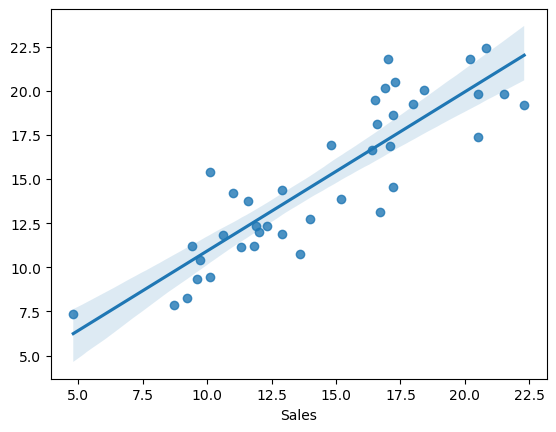

In [44]:
# الان راح نرسم الخط المسنقيم 
# من مكتبه  seaborn  في داله ترسم لك
sns.regplot(x = ytest,y =  ypred)